# Demo: setting up ACCESS-rOM3

When using regional-mom6 as a standalone package, the user must provide the executable and forcing files before they can run the model itself. The regional ACCESS ocean model, rOM3, is a configuration of regional-mom6 supported by ACCESS-NRI, whereby ACCESS-NRI maintains an executable and forcing datasets on NCI (Australia's national HPC system), allowing users with access to run their models out of the box.

## Loading the regional-mom6 environment

To use regional-mom6 on gadi, you'll need to include the following in your ARE session:

```
Module directories: /g/data/vk83/staging/modules
Modules: rmom6
```

## Required NCI projects:
You'll need to be a member of the following projects and also add them to the storage of your ARE session, e.g.,

`Storage: gdata/vk83+gdata/rt52+gdata/ik11`


| name | purpose |
|------|---------|
| vk83 | ACCESS-NRI's MOM6 executable |
| ik11 | GEBCO bathymetry data |
| qv56 | JRA river runoff |
| av17 | ERA5 surface forcing data |

Since this demo is necessarily hardcoded for NCI paths and environments, users outside of Australia should look instead at the machine-agnostic demo, or [CROCODILE-CESM](https://github.com/CROCODILE-CESM/) for users in the US.

## Preamble: Load packages and define workspace paths

To make sure that things are working we recommend starting with the default example defined below.

If this runs ok, then we can change to a domain of our choice and hopefully it runs ok too! If not, check the [README](https://github.com/COSIMA/regional-mom6/blob/main/README.md) and [documentation](https://regional-mom6.readthedocs.io/) for troubleshooting tips.

In [1]:
import os
import matplotlib.pyplot as plt
from pathlib import Path

import regional_mom6 as rmom6
print("using regional-mom6 version " + rmom6.__version__)


expt_name = "kimberly_om3_2k_180926"
project = os.environ["PROJECT"]
user = os.environ["USER"]
scratch = Path(f"/g/data/{project}/{user}")
gdata = Path(f"/g/data/{project}/{user}")
home = Path(f"/home/130/ae7501")
## Place where all the input files go
input_dir = f"{scratch}/mom6_input_directories/{expt_name}/"

## Directory where we'll be running the experiment from
run_dir = f"{home}/mom6_run_directories/2026_September/rom3-rundirs/{expt_name}/"

## Directory for temporary files we don't need long term, like the raw GLORYs downloads
tmp_dir = f"{scratch}/tmp/{expt_name}"

## if directories don't exist, create them
for path in (run_dir, tmp_dir, input_dir):
    os.makedirs(str(path), exist_ok=True)

using regional-mom6 version 1.0.3


## Step 1: Define your experiment

The experiment object, which we've called `expt` below, is the most important part of the `regional-mom6` workflow. It keeps track of everything about your experiment. 
In the next cell, we initialise the experiment object with all of the fundamental things that define our domain. Note that specific details like what datasets to use for the bathymetry or forcing aren't included here- this comes later. 

To make sure that things are working we recommend starting with the default example defined below.

If this runs ok, then we can change to a domain of our choice and hopefully it runs ok too! If not, check the [README](https://github.com/COSIMA/regional-mom6/blob/main/README.md) and [documentation](https://regional-mom6.readthedocs.io/) for troubleshooting tips.

We can log in and use [Copernicus GUI](https://data.marine.copernicus.eu/product/GLOBAL_MULTIYEAR_PHY_001_030/download) to find the latitude-longitude ranges of the domain of choice and then paste below.


In [2]:
expt = rmom6.experiment(
    longitude_extent = [105, 135],                  # The intended edges of your domain. Note that MOM6's c grid means that the tracer grid 
    latitude_extent = [-24, -8],                # (like for bathymetry) will actually be slightly smaller than this               

    date_range = ["2016-12-20", "2021-01-04"],      # This will set the start date of the experiment, and ensure we download the right forcing data 

    resolution = 0.018,                               # Horizontal resolution in degrees. This sets the zonal resolution - under the default grid, 
                                                    # the meridional resolution is scaled to give a `square` grid when measured in km rather than degrees.

    hgrid_type="even_spacing",                      # Type of horizontal grid. Even spacing is the default - check out documentation and other demos
                                                    # for more information about grids.

    number_vertical_layers = 100,                    # Number of vertical layers, not number of interfaces.

    layer_thickness_ratio = 20,                     # Ratio of the deepest layer thickness to the surface layer. 
                                                    # Set higher for more resolution near the surface, negative for higher resolution at the sea floor.

    depth = 5700,                                   # Maximum depth of your domain. This will set the depth of the deepest layer in the vertical coordinate. 
                                                    # Best to have this match the deepest point in your bathymetry, but it doesn't have to.

    minimum_depth = 5,                             # Minimum depth of your domain. Shallower water will be considered land and masked out.

    tidal_constituents=[],                          # You can put your favourite tidal consituents here (e.g. "M2") or remove this line to turn 
                                                    # on all of them (the default behaviour)

    mom_run_dir = run_dir,                          # This is the directory from which you will run your experiment. Namelists and other text files go here.

    mom_input_dir = input_dir,                      # The location for all the data files needed for your experiment. netcdfs go here. 

    boundaries=["north", "south", "east", "west"]   # The boundaries and their orientations. Rectangular domains are easiest, but see 
                                                    # documentation and other demos to see how to set up more complex domains
)

This means that some areas may only have one or two layers between the surface and sea floor. 
For increased stability, consider increasing the minimum depth, or adjusting the vertical coordinate to add more layers near the surface.


After running this step, have a look in the `input_dir` and you'll see that it's started being populated. We now have a horizontal grid (hgrid) and a vertical coordinate (vgrid). These two files are the main building blocks of the experiment. Now, everything else will be regridded to match these grids. 

The grids in regional-mom6 utilise NCAR's [mom6_forge](https://github.com/NCAR/mom6_forge) objects under the hood. To access the raw `netcdf` version of the horizontal grid that MOM6 will see, use `expt.hgrid`. The corresponding `mom6_forge` object can be accessed with `.m6f_hgrid`. The `m6f` object includes some helpful features like accessing the tracer longitudes with `.tlon` or velocity latitudes with `.ulat`

Tracer longitudes (tlon's) in our grid: 
 [105.0090036  105.0270108  105.04501801 ... 134.95498199 134.9729892
 134.9909964 ]

Velocity longitudes (ulat's) in our grid: 
 [105.         105.0180072  105.03601441 ... 134.96398559 134.9819928
 135.        ]

Interface heights in our vertical grid: 
 [0.0000e+00 5.6000e+00 1.1300e+01 1.6900e+01 2.2700e+01 2.8400e+01
 3.4200e+01 4.0000e+01 4.5900e+01 5.1900e+01 5.7900e+01 6.4000e+01
 7.0200e+01 7.6500e+01 8.2900e+01 8.9500e+01 9.6200e+01 1.0310e+02
 1.1020e+02 1.1740e+02 1.2500e+02 1.3280e+02 1.4090e+02 1.4940e+02
 1.5830e+02 1.6760e+02 1.7740e+02 1.8780e+02 1.9890e+02 2.1060e+02
 2.2320e+02 2.3660e+02 2.5100e+02 2.6650e+02 2.8330e+02 3.0140e+02
 3.2090e+02 3.4210e+02 3.6500e+02 3.8990e+02 4.1690e+02 4.4610e+02
 4.7770e+02 5.1180e+02 5.4870e+02 5.8840e+02 6.3100e+02 6.7680e+02
 7.2560e+02 7.7770e+02 8.3310e+02 8.9170e+02 9.5360e+02 1.0188e+03
 1.0870e+03 1.1584e+03 1.2327e+03 1.3098e+03 1.3897e+03 1.4721e+03
 1.5569e+03 1.6439e+03 1.7330e+0

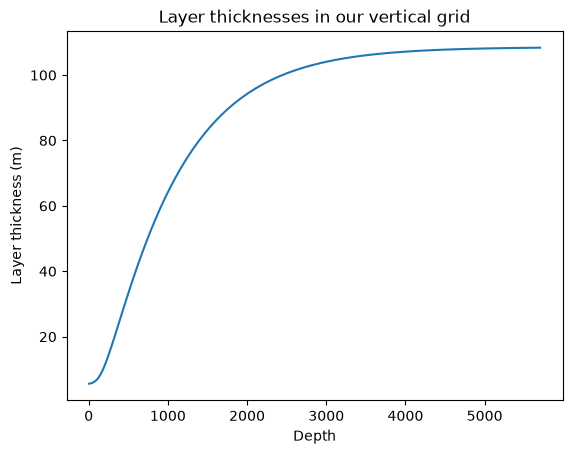

In [3]:
print("Tracer longitudes (tlon's) in our grid: \n",expt.m6f_hgrid.tlon.values[0,:],end = "\n\n")
print("Velocity longitudes (ulat's) in our grid: \n",expt.m6f_hgrid.ulon.values[0,:],end = "\n\n")
print("Interface heights in our vertical grid: \n",expt.vgrid.zi.values.round(1),end = "\n\n")

# Plot the layer thicknesses by calculating the difference between the interface heights
expt.vgrid.zi.diff("zi").plot()
plt.title("Layer thicknesses in our vertical grid"), plt.xlabel("Depth") , plt.ylabel("Layer thickness (m)");

The m6f grid also has a helpful plotting feature that lets you cheaply preview your domain before committing to the expensive regridding steps`

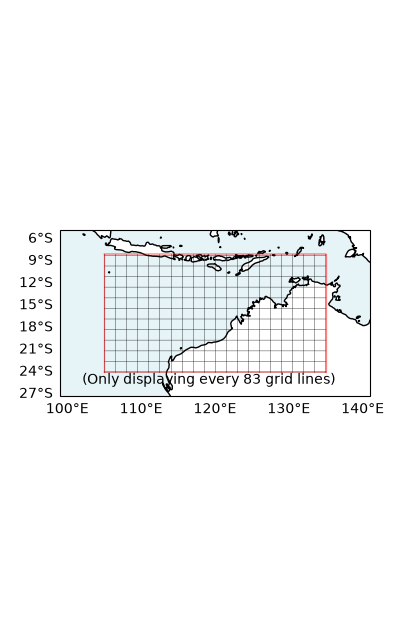

In [4]:
fig = expt.m6f_hgrid.plot()
fig.set_size_inches(4,6)

## Step 2: Download forcing data for your domain
### OR use the Tasmania data we prepared earlier for the demo

*If you're just running this notebook as is, you don't need to download the Tassie forcing data since we did it for you! But you will need this step when running a new domain*

We use the glorys reanalysis product to make the initial condition and boundary forcing files for rOM3. These files can be downloaded from the Copernicusmarine database, but you'll need to make an account here first. 

The method below generates a bash script for downloading the initial conditions and boundary forcing data required for your experiment. Once you run the next cell, you'll need to go to your `tmp` directory (that was defined above, usually in your scratch space), and run the `get_glorys.sh` script. It's best if you start an interactive copyq job for this, as downloads can be large for big domains.


In [5]:
# If you're running your own experiment in a new domain, run this cell
expt.get_glorys(tmp_dir,project)

The script `get_glorys_data.pbs` has been generated at:
  /g/data/nm03/ae7501/tmp/kimberly_om3_2k_180926.
To download the data, qsub 

Important instructions:
1. You will need your Copernicus Marine username and password.
   If you do not have an account, you can create one here: 
   https://data.marine.copernicus.eu/register
2. Follow the instructions below to set up your account properly on gadi using `coperinucmarine login`. You may want to do this first on a login node before trying the pbs job. https://help.marine.copernicus.eu/en/articles/8185007-copernicus-marine-toolbox-credentials-configuration 
3. Depending on the dataset size, the download process may take significant time and resources.



In [6]:
# If you're just using the Tasmania domain for the demo, run this cell to overwrite the `tmp_dir` 
# with one containing the Tassie data you need
tmp_dir = "/g/data/nm03/ae7501/tmp/kimberly_om3_2k_180926"

Either way, after finishing this step, your `tmp_dir` should now have five files: `east_unprocessed.nc`, `west_unprocessed.nc`, `north_unprocessed.nc`, `south_unprocessed.nc` and `ic_unprocessed.nc`. These files don't have to come from GLORYS - you can easily construct them yourself from your favourite forcing dataset. For example, you could use the COSIMA intake catalogue to subset ACCESS-OM2 model data outputs to serve as your forcind data, or even output from another regional MOM6 domain to make a inner, higher resolution nested experiment. 

All you need to do is cut out your desired forcing dataset and make skinny (5 grid cells wide) boundary segment files for the duration of your experiment, and one initial condition file. Name them the same as above, and put them in your `tmp_dir`. 

## 3. Set up bathymetry & forcing files

Now that we have our main experiment object defined, we get it to do all the heavy lifting. Here, just need feed it the path to our bathymetry file of choice, and tell it what the coordinates are called. 

In [7]:
expt.setup_bathymetry(
    bathymetry_path='/g/data/ik11/inputs/GEBCO_2022/GEBCO_2022.nc',
    longitude_coordinate_name='lon',
    latitude_coordinate_name='lat',
    vertical_coordinate_name='elevation',
    )

Setting up bathymetry...if this fails, please follow the printed instructions with your experiment's m6f_bathymetry object, like this: [experiment_obj].m6f_bathymetry. For example, if the output tells you to run mpi_set_from_dataset instead of set_from_dataset. You would do: [experiment_obj].m6f_bathymetry.mpi_set_from_dataset(...)
Slicing source bathymetry to domain: (105.0, 135.0) x (-24.0, -8.0) with buffer 0.5
  Resolution Diagnostics

  Source dataset (GEBCO_2022.nc):
    dlon = 15.0 arcsec  (0.004167°)
    dlat = 15.0 arcsec  (0.004167°)
    dx   ~ 422 m)
    dy   ~ 463 m

  Model grid (T-cell spacing):
    median = 1.92 km
    min    = 1.88 km
    max    = 1.95 km

  Resolution ratio (model dx / dataset dx):
    median = 4.6x
    max    = 4.6x

  Cressman / stats-mask threshold: 12x
  → RECOMMENDED: direct_xesmf_regrid()  (bilinear / conservative)
    Ratio 4.6x is below the threshold where Cressman
    likely provides benefit over xesmf regridding.
**NOTE**
            If bathy

<xarray.Dataset> Size: 55MB
Dimensions:    (ny: 925, nx: 1666)
Dimensions without coordinates: ny, nx
Data variables:
    y          (ny, nx) float64 12MB -23.99 -23.99 -23.99 ... -8.009 -8.009
    x          (ny, nx) float64 12MB 105.0 105.0 105.0 ... 135.0 135.0 135.0
    mask       (ny, nx) int32 6MB 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    depth_raw  (ny, nx) float64 12MB 3.828e+03 4.048e+03 ... 107.0 106.0
    depth      (ny, nx) float64 12MB 3.828e+03 4.048e+03 ... 107.0 106.0
Attributes:
    date_created:  2026-09-18T15:25:43.754485
    title:         MOM6 topography file
    min_depth:     5
    max_depth:     7182.0

Now if you look in the `input_dir`, you'll see a `bathymetry.nc` file. There's also an intermediate file called `bathymetry_raw.nc`. This is a file that's been cut out but not yet regridded - important if you need to do your regridding as a separate job with extra resources, but don't worry about that for now. 

Just like with the grids above, we can directly plot the bathymetry now:

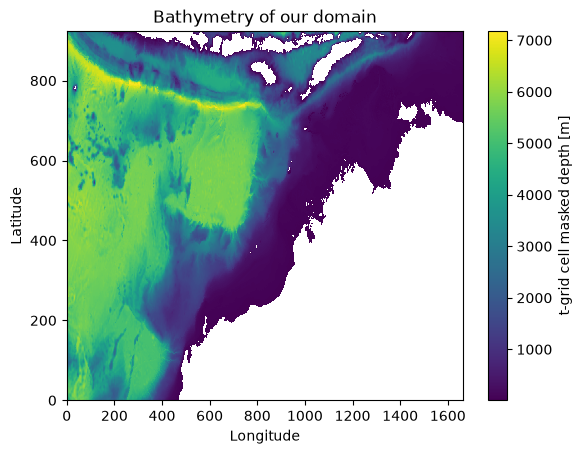

In [8]:
# To add a land mask to the domain, it's easy to just use the .where method to only plot the points where the bathymetry is not zero
fig,ax = plt.subplots()

expt.bathymetry.depth.where(
    expt.bathymetry.mask # This line applies the land mask to the plot, setting land to white
).plot(ax = ax)
ax.set_title("Bathymetry of our domain"), plt.xlabel("Longitude") , plt.ylabel("Latitude");

Next, we pass on the paths to the initial and boundary conditions. These are the GLORYS files that we downloaded earlier to our `tmp_dir`. 

Importantly, if you didn't want to force with GLORYS data, you'll need to modify the`ocean_varnames` dictionary that maps the MOM6 variable names (`yh`, `xh` etc.) to the variable names in the dataset. 

The last thing you need to do is specify which Arakawa grid your input data is on. In the case of the GLORYS dataset, tracers and velocities are on the same grid points, so it's an "A" grid. 

In [13]:
# Mapping dictionary between MOM6 variable names (left) and those in GLORYS (right), which is the source dataset for the forcing files
# If you use a different source dataset, simply replace the GLORYS names with those in your dataset of choice

ocean_varnames = {"time": "time",
                  "yh": "latitude", 
                  "xh": "longitude",
                  "zl": "depth",
                  "eta": "zos",
                  "u": "uo",
                  "v": "vo",
                  "tracers": {"salt": "so", "temp": "thetao"} # You can have as many tracers here as you like, and they will all get regridded to your ICs / BCs
                  }

# Set up the initial condition.
expt.setup_initial_condition(
    tmp_dir + "/ic_unprocessed.nc",
    ocean_varnames,
    arakawa_grid = "A"
    )

# Set up the four boundary conditions.
expt.setup_ocean_state_boundaries(
    Path(tmp_dir),
    ocean_varnames,
    arakawa_grid = "A"
    )

Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid
Setting up Initial Conditions
Regridding Velocities... Done.
Regridding Tracers... Done.
Regridding Free surface... Done.
Saving outputs... Processing north boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid
Done.
Processing south boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid
Done.
Processing east boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid
Done.
Processing west boundary velocity & tracers...Applying Arakawa A grid variable mapping, which is velocities and tracers on the same grid
Done.


Now we've made our initial and boundary conditions, these files are also now in our `input_dir`. The initial conditions can also be plotted via our experiment object. Remember that calling `expt.init_tracers` just returns an xarray object, so everything from there on is just xarray syntax

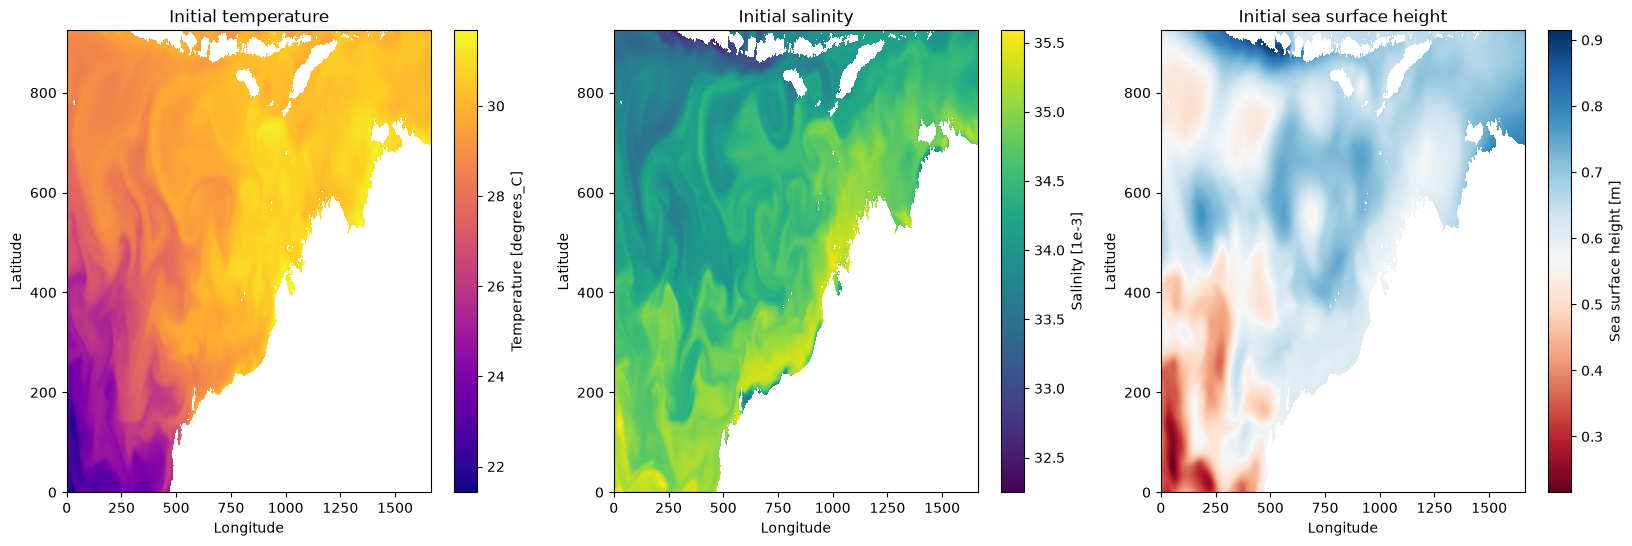

In [12]:
fig,ax = plt.subplots(1,3,figsize=(20, 6))
# Plot the surface values of temperature, salinity and sea surface height for the initial conditions
expt.init_tracers.temp.isel(zl = 0).where(expt.bathymetry.mask).plot(ax=ax[0],cmap = "plasma")
expt.init_tracers.salt.isel(zl = 0).where(expt.bathymetry.mask).plot(ax=ax[1])
expt.init_eta.eta_t.where(expt.bathymetry.mask).plot(ax=ax[2],cmap = "RdBu")
ax[0].set_title("Initial temperature"), ax[1].set_title("Initial salinity"), ax[2].set_title("Initial sea surface height")
for i in ax:
    i.set_xlabel("Longitude"), i.set_ylabel("Latitude")

## 4. Set up the run directory

So far, each of the methods we've run have populated the `input_dir` with data files, like the grids, bathymetry, forcing files etc. The last step is to set up the run directory with the text files that the model needs. These include the `diag_table`, `MOM_input` and `MOM_override` files for MOM6, the `nuopc.runconfig` for the nuopc coupler, and the `config.yaml` file for payu. 

This final step uses all of the information that `regional-mom6` knows about your experiment to write out these files, creating a run directory that's ready to be run with the `payu` scheduler. 

First, we need to copy the template files from `ACCESS-NRI`, which are kept up to date with their MOM6 builds. This can either be done automatically by setting `overwrite = True` and providing a branch with, for example, `branch = M_regional_template`. Or, you can do this manually by navigating to your run directory (specified above) and running the following

`git clone https://github.com/ACCESS-NRI/access-om3-configs.git -b M_regional_template`

Either way, running the following cell will build on this template to set up your model run. Note that this will work even if you change your domain from the Tasmania example - `regional-mom6` makes all the necessary modifications, it just needs initial template files to build on.

**IMPORTANT**
The `overwrite` flag means business. If you set `overwrite=True`, then `regional-mom6` will delete everything in your run directory and re-clone from github. This doesn't affect files in your input directory (all the `.nc` files) but _will_ undo any manual edits you've made in your run directory. With `overwrite=False`, `regional-mom6` instead attempts to modify existing files. It's recommended that you keep track of your experiments yourself with git so you can't accidentally lose any manual modifications you make to the model settings.

In [ ]:
stop

In [14]:
expt.setup_rOM3(branch = "M_regional_template",overwrite=False)

Overwrite set to False. I'll attempt to modify existing files in the directory rather than replacing them entirely.
If any files are missing the run directory, you can get them from the template directory at https://github.com/ACCESS-NRI/access-om3-configs/tree/M_regional_template
Changed NIGLOBAL from 1677 to 1666in MOM_override!
Changed NJGLOBAL from 1358 to 925in MOM_override!


## 6. Run with payu

This step takes place in a terminal on gadi inside your run directory. For further information about the `payu` workflow management tool, see the [documentation](https://payu.readthedocs.io/en/latest/)

1. load payu with

    `module use /g/data/vk83/modules; module load payu`

2. Set up the experiment:

    `payu setup`

2. Run the experiment

    `payu run -f`
